# 02 · ThermalTwin Analysis

Investigates the dual-zone thermodynamic model (Zone A: liquid-cooled GPU, Zone B: air-cooled CPU). Covers static steady-states, step responses, and COP degradation.

In [1]:
import sys, os
os.chdir("/lustre/guillant/C2G-Macro")
sys.path.insert(0, ".")
import numpy as np, matplotlib.pyplot as plt, matplotlib.cm as cm
from c2g_env.physics.thermal import ThermalTwin

tw = ThermalTwin(dt_seconds=300)
print("Zone A T_safe:", tw.T_safe, "°C")
print("Zone B T_amb default:", tw.T_amb, "°C")
print("COP liquid @ default:", tw.cop_liquid())
print("COP air    @ default:", tw.cop_air())

Zone A T_safe: 35.0 °C
Zone B T_amb default: 25.0 °C
COP liquid @ default: 30.0
COP air    @ default: 3.5


## 2.1 Steady-State Temperature vs IT Power

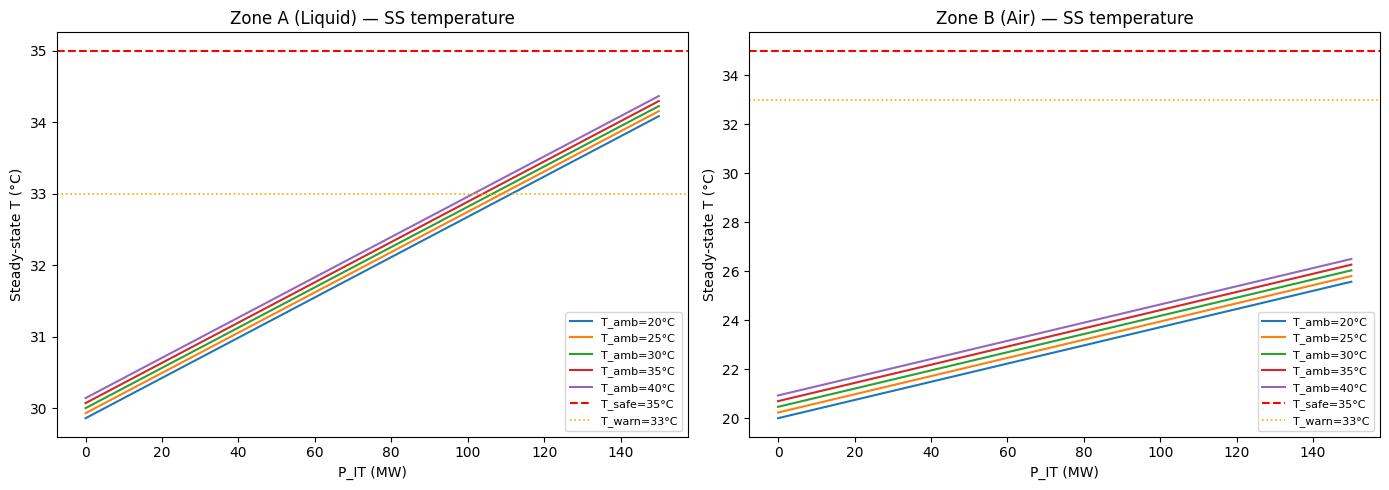

In [2]:
T_amb_vals = [20, 25, 30, 35, 40]
it_A_range = np.linspace(0, 150, 60)   # MW

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for T_a in T_amb_vals:
    T_A_ss, T_B_ss = [], []
    for p_it in it_A_range:
        tw2 = ThermalTwin(dt_seconds=300); tw2.T_amb = T_a
        # Run 500 steps at constant load to find approximate steady-state
        for _ in range(500):
            tw2.step(p_it_A_mw=p_it, p_it_B_mw=p_it * 0.4, hvac_effort=0.7)
        T_A_ss.append(tw2.temp_A)
        T_B_ss.append(tw2.temp_B)
    axes[0].plot(it_A_range, T_A_ss, label=f"T_amb={T_a}°C")
    axes[1].plot(it_A_range, T_B_ss, label=f"T_amb={T_a}°C")

for ax, zone in zip(axes, ["Zone A (Liquid)", "Zone B (Air)"]):
    ax.axhline(tw.T_safe, color="red", ls="--", lw=1.5, label="T_safe=35°C")
    ax.axhline(33, color="orange", ls=":", lw=1.2, label="T_warn=33°C")
    ax.set_xlabel("P_IT (MW)"); ax.set_ylabel("Steady-state T (°C)")
    ax.set_title(f"{zone} — SS temperature"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("notebooks/fig_thermal_ss.png", dpi=120); plt.show()

## 2.2 Step Response — Thermal Inertia

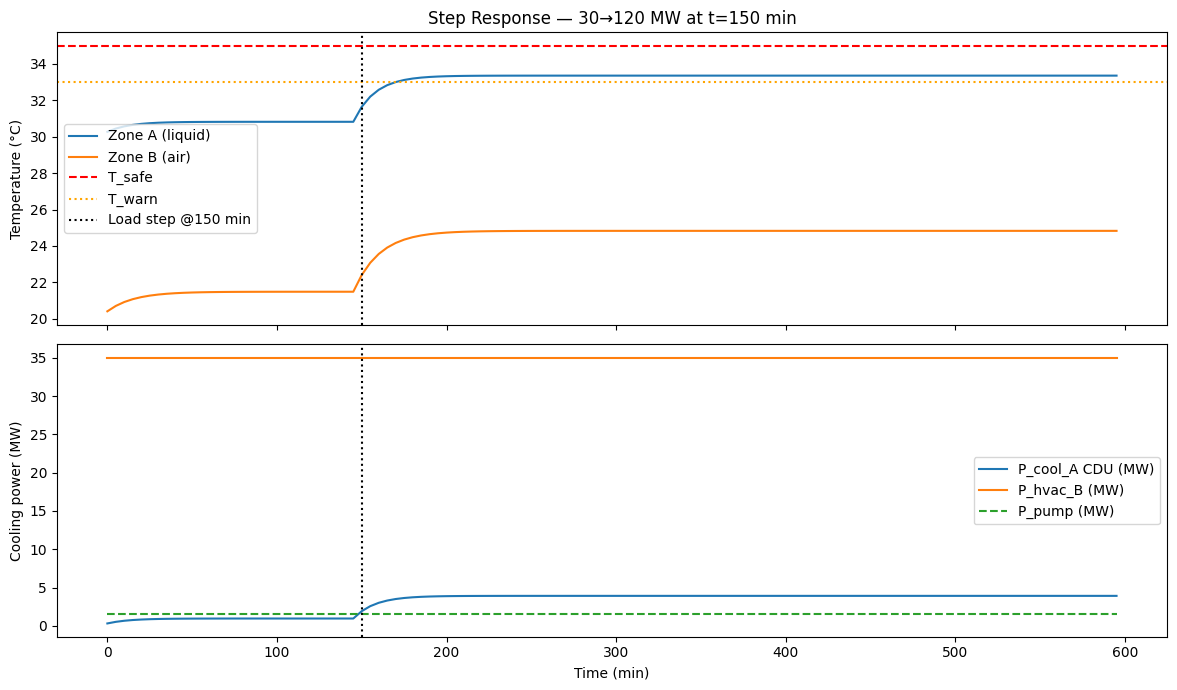

In [3]:
tw3 = ThermalTwin(dt_seconds=300); tw3.T_amb = 28
ticks = 120   # 10 hours
# Ramp: low load for 30 ticks, then step to high load
t_min = np.arange(ticks) * 5
T_A, T_B, P_cool_A, P_hvac_B, P_pump = [], [], [], [], []
for i in range(ticks):
    load = 30.0 if i < 30 else 120.0
    (ta, tb), (pca, phv, ppump) = tw3.step(load, load * 0.4, hvac_effort=0.7)
    T_A.append(ta); T_B.append(tb); P_cool_A.append(pca); P_hvac_B.append(phv); P_pump.append(ppump)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axes[0].plot(t_min, T_A, label="Zone A (liquid)", color="tab:blue")
axes[0].plot(t_min, T_B, label="Zone B (air)",    color="tab:orange")
axes[0].axhline(35, color="red",    ls="--", label="T_safe")
axes[0].axhline(33, color="orange", ls=":",  label="T_warn")
axes[0].axvline(30*5, color="k", ls=":", label="Load step @150 min")
axes[0].set_ylabel("Temperature (°C)"); axes[0].legend(); axes[0].set_title("Step Response — 30→120 MW at t=150 min")

axes[1].plot(t_min, P_cool_A, label="P_cool_A CDU (MW)", color="tab:blue")
axes[1].plot(t_min, P_hvac_B, label="P_hvac_B (MW)", color="tab:orange")
axes[1].plot(t_min, P_pump,   label="P_pump (MW)",   color="tab:green", ls="--")
axes[1].axvline(30*5, color="k", ls=":")
axes[1].set_xlabel("Time (min)"); axes[1].set_ylabel("Cooling power (MW)"); axes[1].legend()
plt.tight_layout(); plt.savefig("notebooks/fig_thermal_step.png", dpi=120); plt.show()

## 2.3 HVAC Effort Sweep — Cooling vs Temperature Trade-off

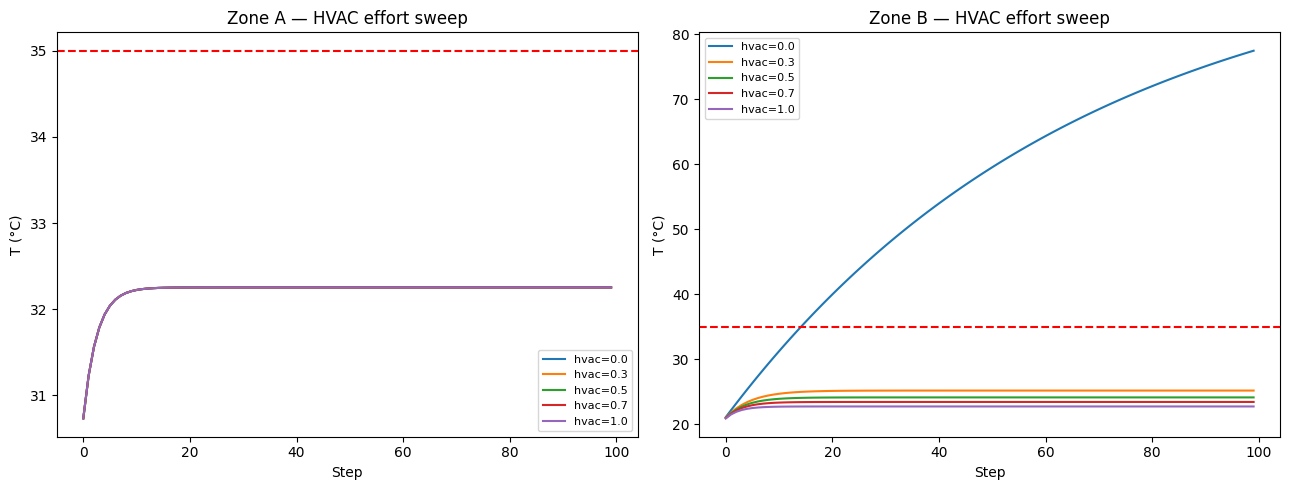

In [4]:
efforts = [0.0, 0.3, 0.5, 0.7, 1.0]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for eff in efforts:
    tw_e = ThermalTwin(dt_seconds=300); tw_e.T_amb = 30
    TA_e, TB_e = [], []
    for _ in range(100):
        (ta, tb), _ = tw_e.step(80.0, 32.0, hvac_effort=eff)
        TA_e.append(ta); TB_e.append(tb)
    axes[0].plot(TA_e, label=f"hvac={eff}")
    axes[1].plot(TB_e, label=f"hvac={eff}")
for ax, zone in zip(axes, ["Zone A", "Zone B"]):
    ax.axhline(35, color="red", ls="--"); ax.set_xlabel("Step"); ax.set_ylabel("T (°C)")
    ax.set_title(f"{zone} — HVAC effort sweep"); ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig("notebooks/fig_thermal_hvac_sweep.png", dpi=120); plt.show()

## 2.4 COP Degradation — Ambient Temperature

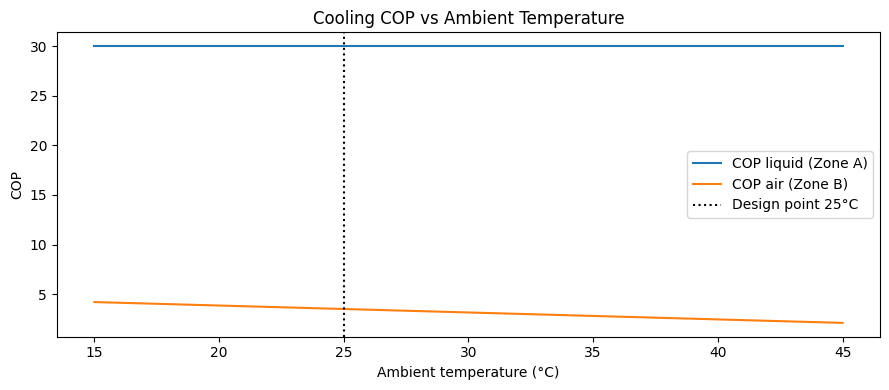

In [5]:
T_amb_range = np.linspace(15, 45, 100)
cop_liq_vals, cop_air_vals = [], []
for T in T_amb_range:
    tw4 = ThermalTwin(dt_seconds=300); tw4.T_amb = T
    cop_liq_vals.append(tw4.cop_liquid())
    cop_air_vals.append(tw4.cop_air())

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(T_amb_range, cop_liq_vals, label="COP liquid (Zone A)")
ax.plot(T_amb_range, cop_air_vals, label="COP air (Zone B)")
ax.axvline(25, color="k", ls=":", label="Design point 25°C")
ax.set_xlabel("Ambient temperature (°C)"); ax.set_ylabel("COP")
ax.set_title("Cooling COP vs Ambient Temperature"); ax.legend()
plt.tight_layout(); plt.savefig("notebooks/fig_thermal_cop.png", dpi=120); plt.show()

## 2.5 Cooling Fault Injection — Transition Behaviour

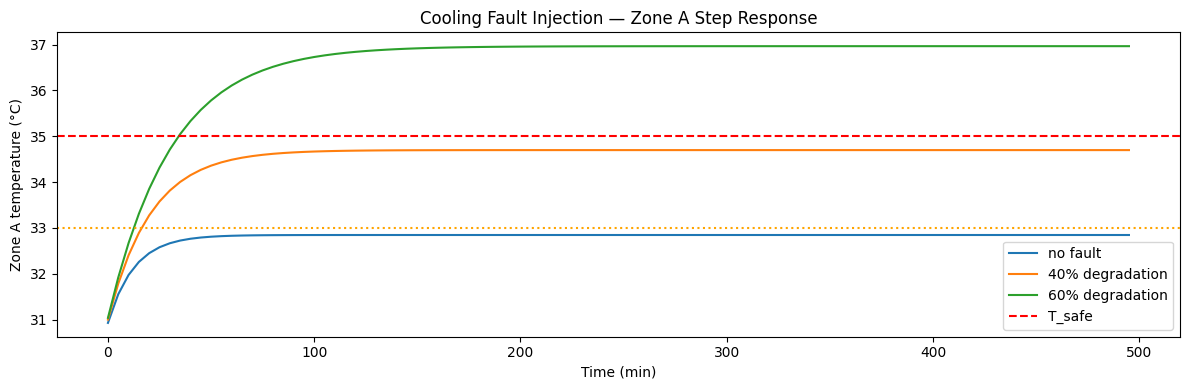

In [6]:
fig, ax = plt.subplots(figsize=(12, 4))
for fault_factor, label in [(1.0, "no fault"), (0.6, "40% degradation"), (0.4, "60% degradation")]:
    tw5 = ThermalTwin(dt_seconds=300); tw5.T_amb = 32
    if fault_factor < 1.0:
        tw5.set_cooling_fault(True, fault_factor)
    temps = []
    for _ in range(100):
        (ta, _), _ = tw5.step(100.0, 40.0, hvac_effort=0.7)
        temps.append(ta)
    ax.plot(np.arange(100)*5, temps, label=label)
ax.axhline(35, color="red", ls="--", label="T_safe"); ax.axhline(33, color="orange", ls=":")
ax.set_xlabel("Time (min)"); ax.set_ylabel("Zone A temperature (°C)")
ax.set_title("Cooling Fault Injection — Zone A Step Response"); ax.legend()
plt.tight_layout(); plt.savefig("notebooks/fig_thermal_fault.png", dpi=120); plt.show()